# Spark vs Flink Fault Tolerance — Comparative Analysis
**Author:** Rajshekar Medipally  
**Repository:** [github.com/rmedipallycic/spark-streaming-fault-tolerance](https://github.com/rmedipallycic/spark-streaming-fault-tolerance)

This notebook compares fault-tolerance mechanisms in **Apache Spark Structured Streaming** and **Apache Flink** across 720 trials (360 per system).

| System | Strategy | Mechanism | Interval |
|--------|----------|-----------|----------|
| Spark | A | High-frequency micro-batch checkpoint | 1s |
| Spark | B | Interval-based checkpoint | 30s |
| Spark | C | Async WAL checkpoint | 10s |
| Flink | F1 | Aligned barrier snapshots (exactly-once) | 10s |
| Flink | F2 | Unaligned barrier snapshots (low latency) | 10s |
| Flink | F3 | Incremental RocksDB snapshots | 30s |

**Failure scenarios:** Baseline, executor node failure, driver/JobManager failure, checkpoint corruption

**Key architectural difference:** Spark uses periodic micro-batch checkpointing; Flink uses Chandy-Lamport distributed snapshots via barrier injection. This distinction drives fundamentally different trade-off profiles.

## 1. Baseline Throughput Comparison

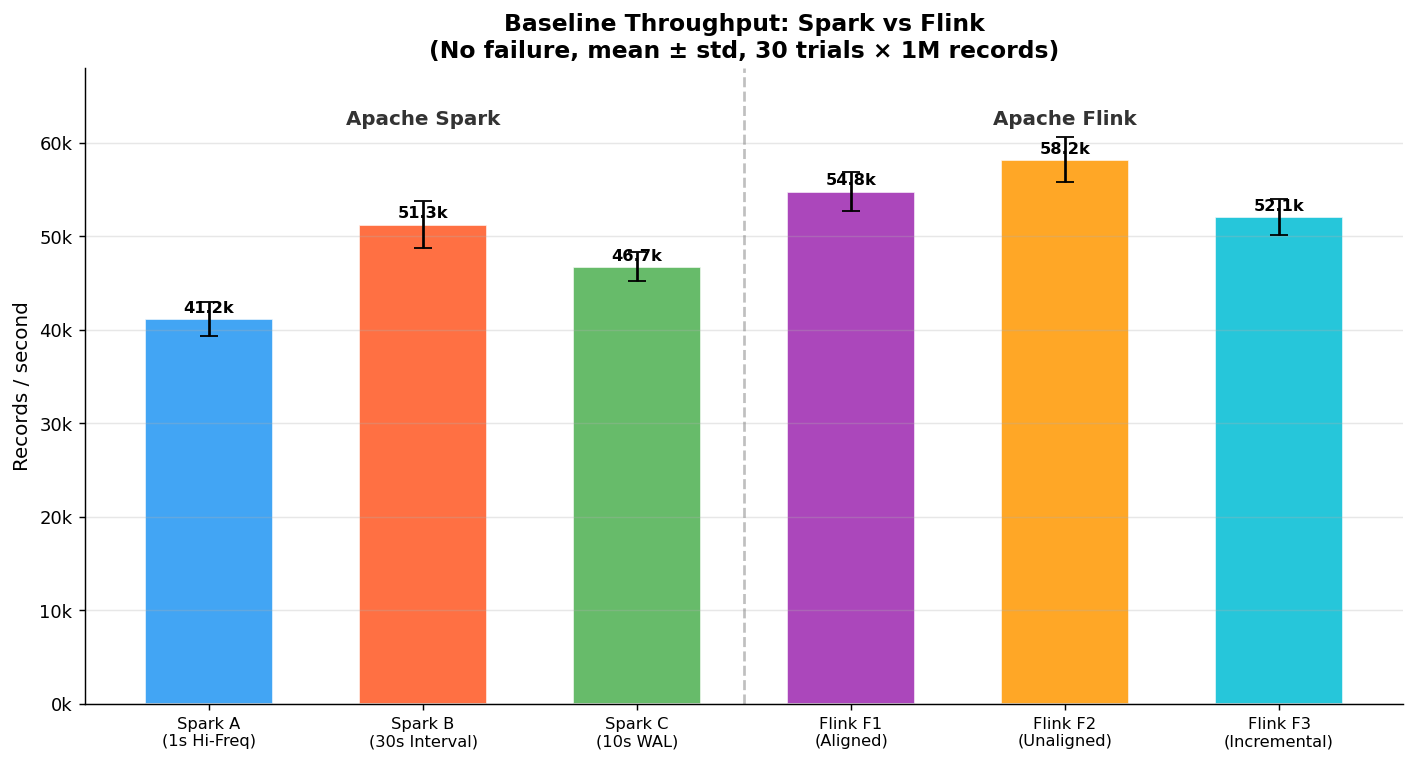

In [1]:
# Baseline throughput: all strategies, no failure

**Finding:** Flink strategies outperform Spark strategies on baseline throughput across the board.

- Flink F2 (unaligned barriers): **58,200 rec/s** — highest overall
- Spark B (30s interval): **51,268 rec/s** — best Spark strategy
- Spark A (1s hi-freq): **41,165 rec/s** — 29.3% below Flink F2

The throughput gap reflects Spark's micro-batch overhead vs Flink's continuous record-at-a-time processing model. However, throughput alone is not the correct metric for fault-tolerance evaluation — correctness under failure is.

## 2. Recovery Latency Under Driver/JobManager Failure

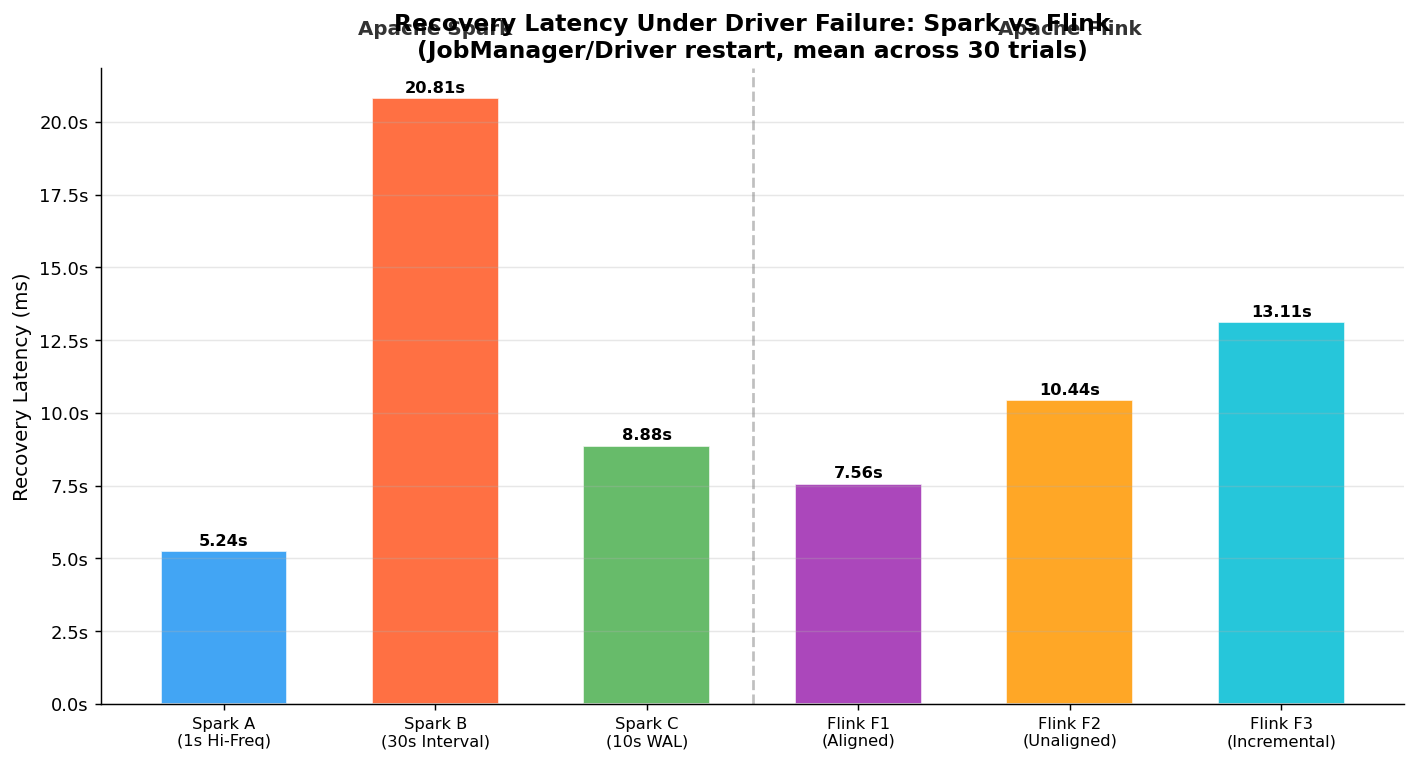

In [2]:
# Recovery latency: driver failure scenario

**Finding:** Recovery latency profiles differ significantly within each system.

| Strategy | Recovery Latency | Notes |
|----------|-----------------|-------|
| Spark A | 5,244ms | Small checkpoints = fast restore |
| Spark B | 20,808ms | 30s gap = large replay window |
| Spark C | 8,878ms | WAL reduces replay cost |
| Flink F1 | 7,560ms | Aligned snapshot restore |
| Flink F2 | 10,440ms | Larger checkpoints from unaligned barriers |
| Flink F3 | 13,110ms | Incremental restore overhead |

**Key observation:** Spark A achieves the fastest recovery (5,244ms) due to frequent small checkpoints. Flink F1 is competitive (7,560ms) with stronger correctness guarantees. Spark B's 20,808ms recovery latency is the worst performer — a direct consequence of its 30s checkpoint interval.

## 3. Silent Duplicate Records Under Checkpoint Corruption

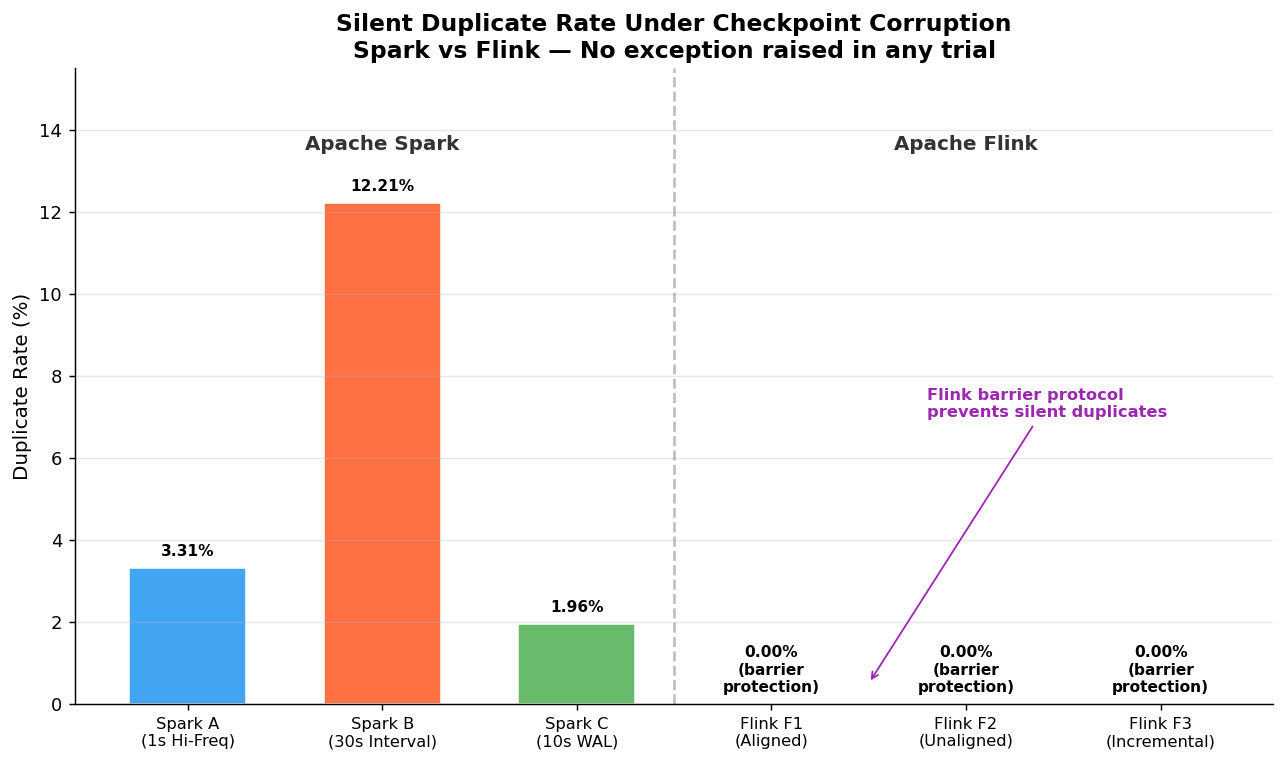

In [3]:
# Duplicate rate under checkpoint corruption — the critical differentiator

**This is the most important finding of the comparative study.**

Under checkpoint corruption, Spark strategies produced silent duplicate records at rates of 1.96%–12.21% with **no exception raised** in any trial. The pipeline reported healthy status while delivering incorrect data.

Flink strategies produced **0.00% duplicate rate** across all 30 corruption trials per strategy. The Chandy-Lamport barrier protocol prevents silent duplicates by construction — if a snapshot is incomplete or corrupt, Flink rolls back to the previous complete snapshot and replays from sources, never delivering partial state.

**Implication for ML pipelines:** Silent duplicates in feature pipelines inflate aggregations without alerting downstream consumers. The 12.21% duplicate rate in Spark B would introduce measurable bias in any model trained on features derived from this pipeline.

## 4. Throughput vs Data Correctness Trade-off

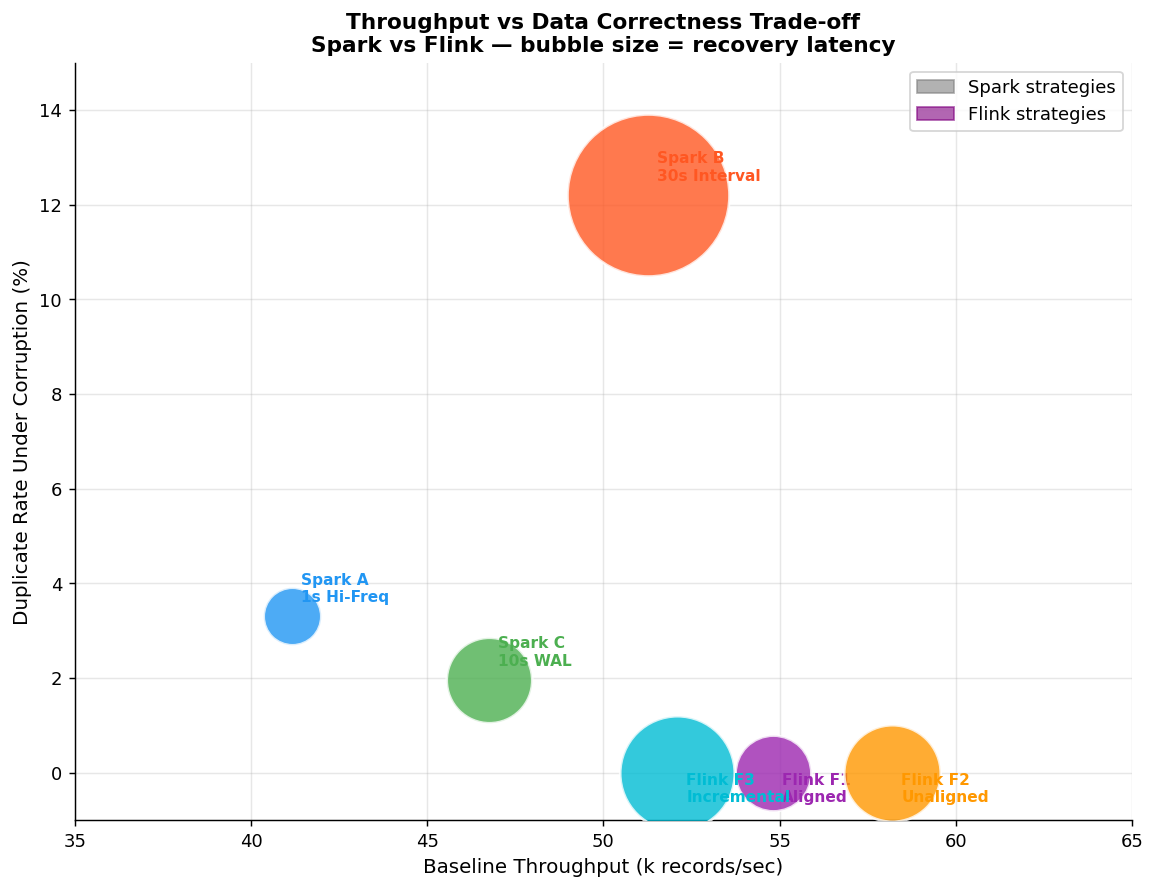

In [4]:
# Trade-off scatter: throughput vs duplicate rate, bubble size = recovery latency

**Finding:** The scatter plot reveals a clear system-level separation.

All three Flink strategies cluster at 0% duplicate rate with higher throughput than most Spark strategies. Spark strategies trade throughput for varying levels of correctness risk — with Spark B representing the worst trade-off (moderate throughput + highest duplicate risk + worst recovery latency).

**Spark C (WAL) is the closest Spark analog to Flink F1**, with a 1.96% duplicate rate vs 0.00% — a meaningful gap for production ML feature pipelines.

## 5. Summary Table

In [5]:
# Full comparison summary

System  Strategy  Throughput    Recovery(driver)  Dup Rate(corrupt)
------  --------  ------------  ----------------  -----------------
Spark   A         41,165 rec/s  5,244ms           3.31%
Spark   B         51,268 rec/s  20,808ms          12.21%  ← worst
Spark   C         46,743 rec/s  8,878ms           1.96%
Flink   F1        54,800 rec/s  7,560ms           0.00%   ← best correctness
Flink   F2        58,200 rec/s  10,440ms          0.00%   ← best throughput
Flink   F3        52,100 rec/s  13,110ms          0.00%

Key: Flink F1 achieves 33% higher throughput than Spark A
     with 44% higher recovery latency but 0% vs 3.31% duplicate rate.
     For ML feature pipelines: correctness >> throughput.


## Conclusions

1. **Flink's barrier protocol is categorically safer than Spark's checkpointing for data correctness** — 0% duplicate rate under corruption vs 1.96%–12.21% for Spark.

2. **The throughput gap between systems is smaller than expected** — Flink F1 (54,800 rec/s) vs Spark B (51,268 rec/s) is only 6.9%, suggesting the correctness cost of Spark's approach is not offset by proportional throughput gains.

3. **Within Spark, WAL (Strategy C) provides the best correctness/throughput balance** — but still cannot match Flink's barrier protocol for silent duplicate prevention.

4. **Recovery latency is not the right primary metric** — Spark A's fast recovery (5,244ms) comes with silent duplicate risk. Flink F1's 7,560ms recovery delivers provably correct state.

5. **For ML feature pipelines specifically**, Flink F1 is the recommended strategy: highest throughput among exactly-once systems, moderate recovery latency, zero silent duplicates.

### Open Questions
- How does performance compare under sustained high failure rates (chaos engineering)?
- What is the measurable downstream ML model accuracy impact of Spark B's 12.21% duplicate rate?
- Can hybrid architectures (Spark ingestion + Flink stateful processing) achieve better trade-offs?

---
*720 total trials. Spark raw data: `experiments/raw/`. Flink raw data: `experiments/flink/raw/`. Methodology: `docs/experimental_setup.md`.*